# Configurações Ambiente

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from unidecode import unidecode
import geopandas as gpd

# Manipulação das tabelas

## Fuction

In [3]:
def add_region(df,column):
  region = {
    'SP': 'Sudeste',
    'RJ': 'Sudeste',
    'MG': 'Sudeste',
    'ES': 'Sudeste',

    'RS': 'Sul',
    'SC': 'Sul',
    'PR': 'Sul',

    'BA': 'Nordeste',
    'PE': 'Nordeste',
    'CE': 'Nordeste',
    'RN': 'Nordeste',
    'PB': 'Nordeste',
    'SE': 'Nordeste',
    'MA': 'Nordeste',
    'PI': 'Nordeste',
    'AL': 'Nordeste',

    'GO': 'Centro-Oeste',
    'DF': 'Centro-Oeste',
    'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste',

    'AM': 'Norte',
    'PA': 'Norte',
    'AC': 'Norte',
    'RO': 'Norte',
    'AP': 'Norte',
    'RR': 'Norte',
    'TO': 'Norte'}

  return df.assign(region=df[column].map(region))

In [4]:
def limpar_texto(texto):
    if pd.isna(texto):
        return []

    texto = texto.lower()
    texto = unidecode(texto)  # remove acentos
    texto = re.sub(r'[^a-z\s]', '', texto)

    palavras = texto.split()

    # singular simples
    palavras = [p[:-1] if p.endswith('s') and len(p) > 4 else p for p in palavras]

    palavras = [
        p for p in palavras
        if p not in stop_words and len(p) > 2
    ]

    return palavras

In [5]:
def cohort_tables(df, grupo):

    base = df[df['first_purchase_sla'] == grupo]

    cohort_counts = base.pivot_table(index='cohort_date', columns='cohort_index', values='num_customers', aggfunc='sum')

    cohort_sizes = cohort_counts.iloc[:, 0]

    cohort_retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

    return cohort_retention, cohort_counts

In [6]:
region_colors = {
    'Norte': '#4C78A8',
    'Nordeste': '#F58518',
    'Centro-Oeste': '#54A24B',
    'Sudeste': '#E45756',
    'Sul': '#72B7B2'
}


## Orders

In [7]:
df_orders = pd.read_csv('./data/olist_orders_dataset.csv', sep=',')

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
columns_time = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

df_orders[columns_time] = df_orders[columns_time].apply(pd.to_datetime)

df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [9]:
df_orders['flag_order_complete'] = (
    df_orders['order_approved_at'].notna() &
    df_orders['order_delivered_carrier_date'].notna() &
    df_orders['order_delivered_customer_date'].notna()
)

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_order_complete
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True


## Order_items

In [10]:
df_items = pd.read_csv('./data//olist_order_items_dataset.csv', sep=',')

df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

df_items['total_price'] = df_items['price'] + df_items['freight_value']

In [12]:
df_items_agg = df_items.groupby('order_id').agg({
    'order_item_id': 'max', #Quantidade de item no pedido
    'price': 'sum', #Preço total do pedido
    'freight_value': 'sum', #Valor do frete
    'total_price': 'sum' #Preço total do pedido + frete
}).reset_index()

## Customers

In [13]:
df_customers = pd.read_csv('./data/olist_customers_dataset.csv', sep=',')

df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
df_customers = add_region(df_customers, 'customer_state')

df_customers['region'].value_counts()

region
Sudeste         68266
Sul             14148
Nordeste         9394
Centro-Oeste     5782
Norte            1851
Name: count, dtype: int64

## Review

In [15]:
df_review = pd.read_csv('./data/olist_order_reviews_dataset.csv', sep=',')

df_review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [16]:
df_review['review_creation_date'] = pd.to_datetime(df_review['review_creation_date'])
df_review['review_answer_timestamp'] = pd.to_datetime(df_review['review_answer_timestamp'])

In [17]:
df_review['with_review_title'] = df_review['review_comment_title'].notnull()
df_review['with_review_message'] = df_review['review_comment_message'].notnull()

## Sellers

In [18]:
df_sellers = pd.read_csv('./data/olist_sellers_dataset.csv', sep=',')

df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [19]:
df_sellers = add_region(df_sellers, 'seller_state')

df_sellers['region'].value_counts()

region
Sudeste         2287
Sul              668
Centro-Oeste      79
Nordeste          56
Norte              5
Name: count, dtype: int64

# Estrutura


**Estrutura - Análises**
- **Crescimento**: Provar que houve crescimento de pedidos e receita durante o periodo registrado -> Receita x Pedido, Ticket Médio.
- **Expansão regional**: Entender onde o crescimento aconteceu -> Receita por região, top estados (Mapa de calor)
- **Logística**: Descobrir eficiencia logistica -> SLA Médio por região, média de frete por regição, pedido atrasado por região.
- **Satisfação do cliente**: Impactos da logistica na experiência no cliente -> Distribuição dos scores, barras de review médio atrasados x no prazo, correlação de estados review médio x atraso e  review médio x frete médio.
- **Recomendações** -> Incentivar sellers locais, Frete inteligente e SLA segmentado.

## Crescimento

In [20]:
crescimento = df_orders[(df_orders['flag_order_complete'] == True) & (df_orders['order_status'] == 'delivered') & (df_orders['order_purchase_timestamp'] > '2017-01-01')].merge(df_items_agg, on='order_id', how='left')
crescimento.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_order_complete,order_item_id,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,1,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,1,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,1,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,1,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,1,19.90,8.72,28.62


In [21]:
month_revenue = crescimento.groupby(crescimento['order_purchase_timestamp'].dt.to_period('M')
).agg({
    'order_id': 'count',
    'total_price': 'sum'
}).reset_index()

month_revenue.columns = ['month', 'orders', 'revenue']

month_revenue['month'] = month_revenue['month'].astype(str)

month_revenue['AoV'] = round(month_revenue['revenue']/month_revenue['orders'],2)

month_revenue['revenue_m'] = month_revenue['revenue']/1000

month_revenue['revenue_M'] = month_revenue['revenue']/1000_000

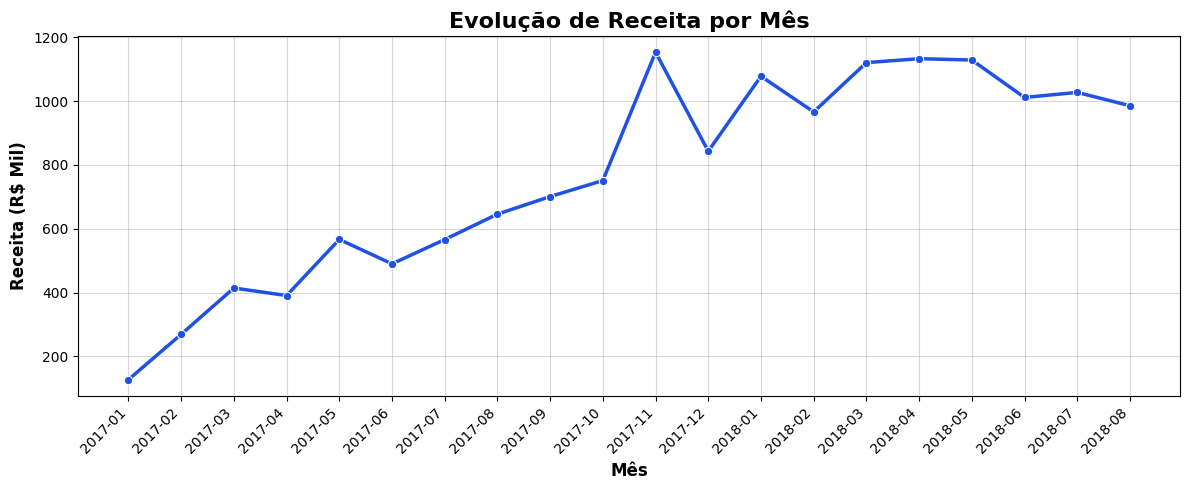

In [22]:
plt.figure(figsize=(12,5))

ax = sns.lineplot(
    data=month_revenue,
    x='month',
    y='revenue_m',
    marker='o',
    linewidth=2.5,
    color='#1F51E5'
)

plt.title('Evolução de Receita por Mês', fontsize=16, weight='bold')

plt.xlabel('Mês', fontsize=12, weight='bold')
plt.ylabel('Receita (R$ Mil)', fontsize=12, weight='bold')

plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', alpha=0.5)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

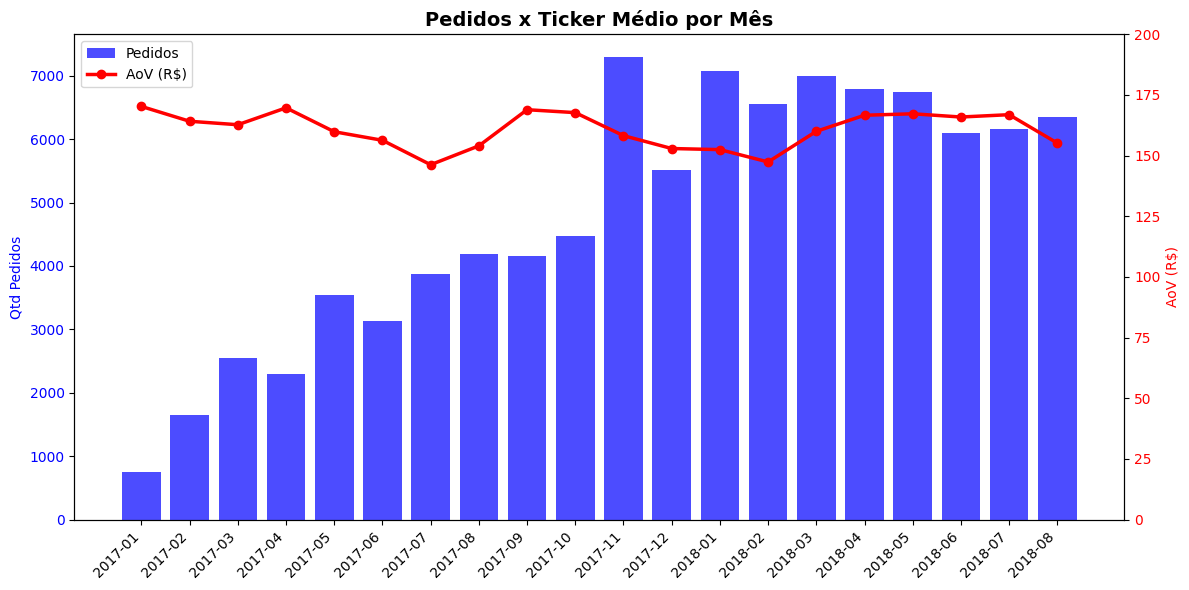

In [23]:
fig, ax1 = plt.subplots(figsize=(12,6))
plt.xticks(rotation=45, ha='right')

bars = ax1.bar(
    month_revenue['month'],
    month_revenue['orders'],
    color='blue',
    alpha=0.7,
    label='Pedidos'
)

ax1.set_ylabel('Qtd Pedidos', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

line = ax2.plot(
    month_revenue['month'],
    month_revenue['AoV'],
    color='red',
    marker='o',
    linewidth=2.5,
    label='AoV (R$)'
)
plt.ylim(0, 200)
ax2.set_ylabel('AoV (R$)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# JUNTA AS LEGENDAS DOS DOIS EIXOS
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

plt.title('Pedidos x Ticker Médio por Mês', fontsize=14, weight='bold')

ax1.grid(axis='x', alpha=0)
ax1.grid(axis='y', alpha=0)
ax2.grid(axis='y', alpha=0)
plt.tight_layout()
plt.show()

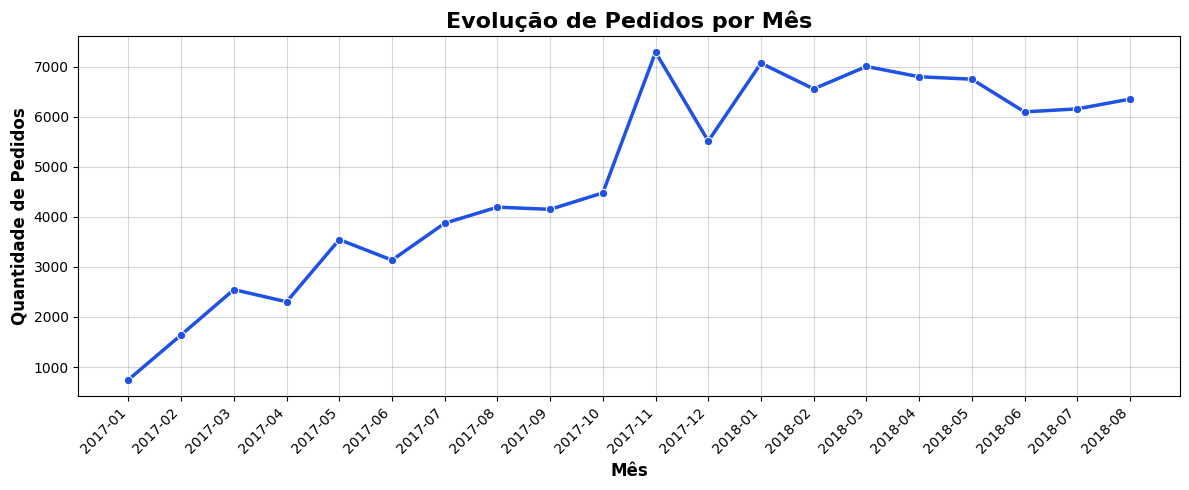

In [24]:
plt.figure(figsize=(12,5))

ax = sns.lineplot(
    data=month_revenue,
    x='month',
    y='orders',
    marker='o',
    linewidth=2.5,
    color='#1F51E5'
)

plt.title('Evolução de Pedidos por Mês', fontsize=16, weight='bold')

plt.xlabel('Mês', fontsize=12, weight='bold')
plt.ylabel('Quantidade de Pedidos', fontsize=12, weight='bold')

plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', alpha=0.5)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

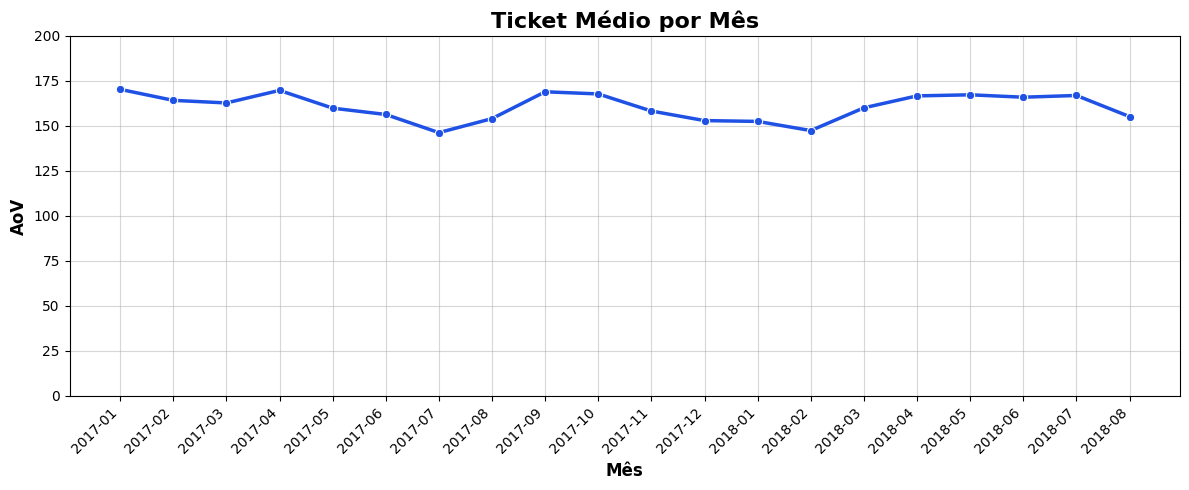

In [25]:
plt.figure(figsize=(12,5))

ax = sns.lineplot(
    data=month_revenue,
    x='month',
    y='AoV',
    marker='o',
    linewidth=2.5,
    color='#1F51E5'
)


plt.title('Ticket Médio por Mês', fontsize=16, weight='bold')

plt.xlabel('Mês', fontsize=12, weight='bold')
plt.ylabel('AoV', fontsize=12, weight='bold')

plt.ylim(0, 200)


plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', alpha=0.5)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Expansão regional

In [26]:
expansao = df_orders[(df_orders['flag_order_complete'] == True) & (df_orders['order_status'] == 'delivered') & (df_orders['order_purchase_timestamp'] > '2017-01-01')].merge(df_customers[['customer_id', 'customer_state', 'region']], on='customer_id', how='left')
expansao = expansao.merge(df_items_agg, on='order_id', how='left')
expansao.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_order_complete,customer_state,region,order_item_id,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,SP,Sudeste,1,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,BA,Nordeste,1,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,GO,Centro-Oeste,1,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,RN,Nordeste,1,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,SP,Sudeste,1,19.90,8.72,28.62


In [27]:
expansao_regiao = expansao.groupby('region').agg({
    'order_id': 'count',
    'total_price': 'sum'
}).reset_index()

expansao_regiao.columns = ['region', 'orders', 'revenue']

In [28]:
expansao_regiao['revenue_share'] = round((expansao_regiao['revenue'] / expansao_regiao['revenue'].sum()) * 100,2)

expansao_regiao = expansao_regiao.sort_values(by='revenue_share', ascending=False)

expansao_regiao['revenue_m'] = expansao_regiao['revenue'] / 1000_000

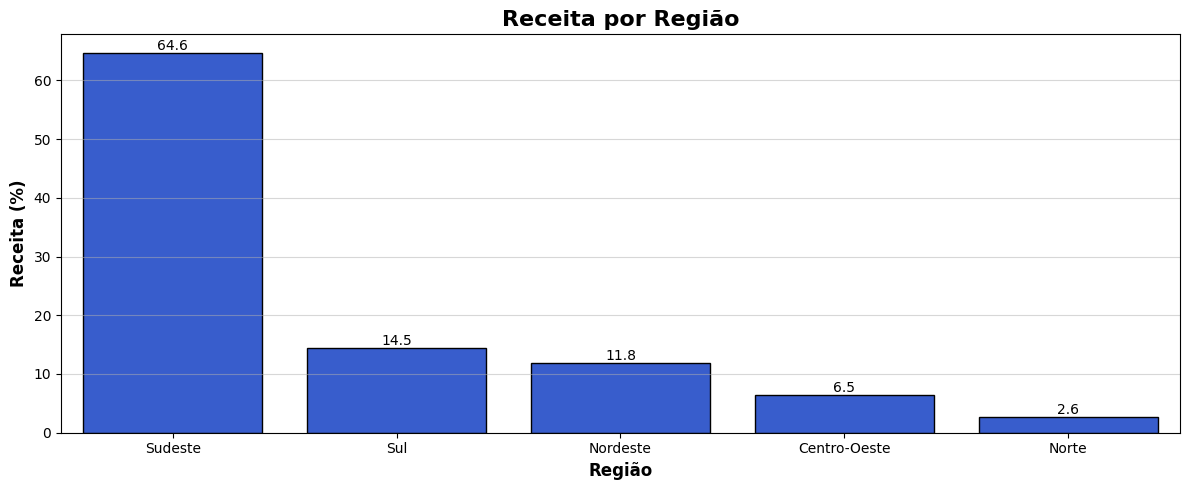

In [29]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=expansao_regiao,
    x='region',
    y='revenue_share',
    color='#1F51E5',
    edgecolor='black'
)

plt.title('Receita por Região', fontsize=16, weight='bold')
plt.xlabel('Região', fontsize=12, weight='bold')
plt.ylabel('Receita (%)', fontsize=12, weight='bold')

plt.grid(axis='y', alpha=0.5)

for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f'{height:.1f}',
        (p.get_x() + p.get_width()/2., height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [30]:
expansao_state = expansao.groupby('customer_state').agg({
    'order_id': 'count',
    'total_price': 'sum'
}).reset_index()

expansao_state.columns = ['state', 'orders', 'revenue']

In [31]:
expansao_state['revenue_share'] = round((expansao_state['revenue'] / expansao_state['revenue'].sum()) * 100,2)

expansao_state = expansao_state.sort_values(by='revenue_share', ascending=False)

expansao_state['revenue_m'] = expansao_state['revenue'] / 1000_000


expansao_state = add_region(expansao_state, 'state')

In [32]:
expansao_state.head()

,state,orders,revenue,revenue_share,revenue_m,region
25,SP,40393,5753948.44,37.44,5.753948,Sudeste
18,RJ,12308,2046134.84,13.31,2.046135,Sudeste
10,MG,11316,1813662.56,11.80,1.813663,Sudeste
22,RS,5325,857826.63,5.58,0.857827,Sul
17,PR,4903,779214.08,5.07,0.779214,Sul


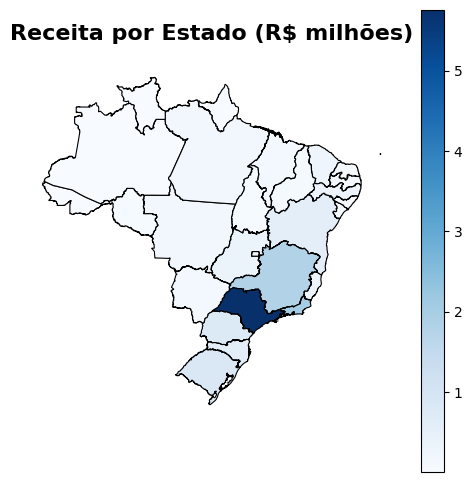

In [33]:
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
br = gpd.read_file(url)

uf_map = {
    'Acre':'AC','Alagoas':'AL','Amapá':'AP','Amazonas':'AM','Bahia':'BA',
    'Ceará':'CE','Distrito Federal':'DF','Espírito Santo':'ES','Goiás':'GO',
    'Maranhão':'MA','Mato Grosso':'MT','Mato Grosso do Sul':'MS',
    'Minas Gerais':'MG','Pará':'PA','Paraíba':'PB','Paraná':'PR',
    'Pernambuco':'PE','Piauí':'PI','Rio de Janeiro':'RJ',
    'Rio Grande do Norte':'RN','Rio Grande do Sul':'RS',
    'Rondônia':'RO','Roraima':'RR','Santa Catarina':'SC',
    'São Paulo':'SP','Sergipe':'SE','Tocantins':'TO'
}

br['state'] = br['name'].map(uf_map)

mapa = br.merge(expansao_state, on='state', how='left')

fig, ax = plt.subplots(figsize=(6,6))


mapa.plot(
    column='revenue_m',
    cmap='Blues',
    linewidth=0.8,
    legend=True,
    edgecolor='black',
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    }
)

ax.set_title(
    'Receita por Estado (R$ milhões)',
    fontsize=16,
    weight='bold',
    pad=15
)

ax.axis('off')

plt.show()

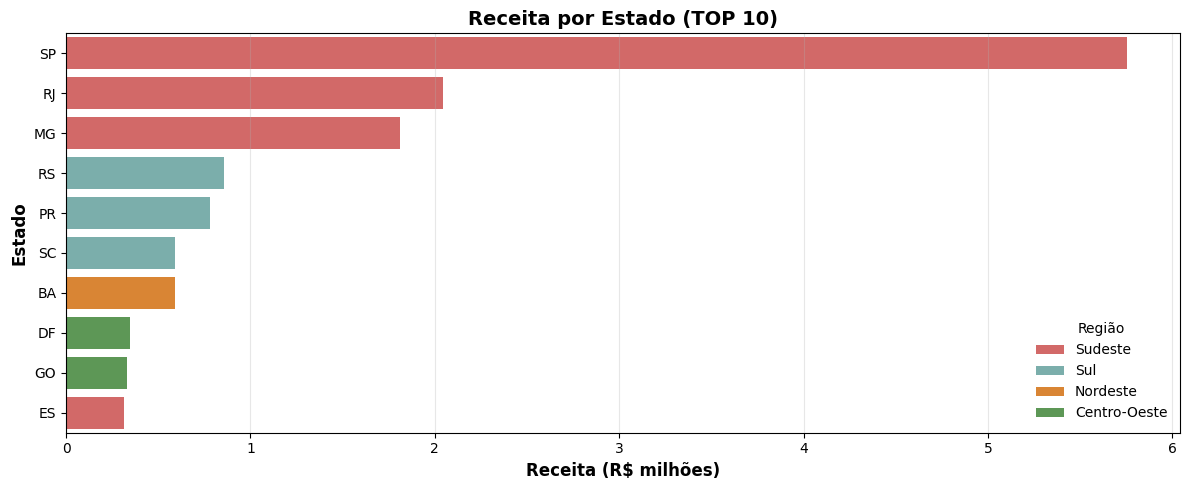

In [34]:
fig, ax = plt.subplots(figsize=(12,5))

bars = sns.barplot(
    data=expansao_state.head(10),
    x='revenue_m',
    y='state',
    hue='region',
    palette=region_colors
)

ax.set_title(
    'Receita por Estado (TOP 10)',
    fontsize=14,
    weight='bold'
)

ax.set_xlabel('Receita (R$ milhões)', fontsize=12, weight='bold')
ax.set_ylabel('Estado', fontsize=12, weight='bold')

ax.grid(axis='x', alpha=0.3)

ax.legend(
    title='Região',
    frameon=False,
    loc='lower right'
)

plt.tight_layout()
plt.show()

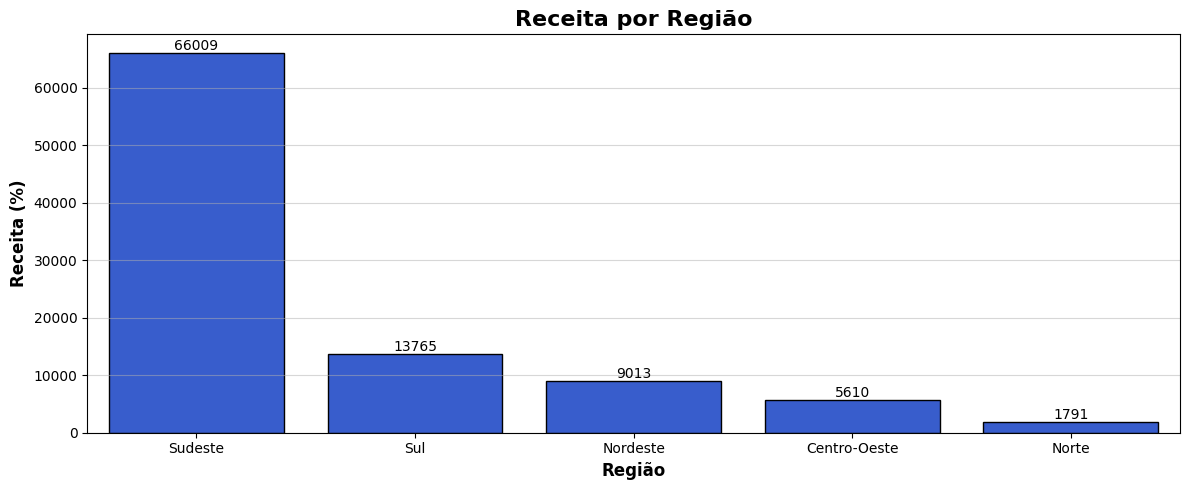

In [35]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=expansao_regiao,
    x='region',
    y='orders',
    color='#1F51E5',
    edgecolor='black'
)

plt.title('Receita por Região', fontsize=16, weight='bold')
plt.xlabel('Região', fontsize=12, weight='bold')
plt.ylabel('Receita (%)', fontsize=12, weight='bold')

plt.grid(axis='y', alpha=0.5)

for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f'{height:.0f}',
        (p.get_x() + p.get_width()/2., height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Logística

In [36]:
logistica = df_orders[(df_orders['flag_order_complete'] == True) & (df_orders['order_purchase_timestamp'] > '2017-01-01')]

logistica = logistica.merge(df_customers[['customer_id', 'customer_state', 'region']], on='customer_id', how='left')

logistica = logistica.merge(df_items_agg, on='order_id', how='left')

logistica.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_order_complete,customer_state,region,order_item_id,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,SP,Sudeste,1,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,BA,Nordeste,1,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,GO,Centro-Oeste,1,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,True,RN,Nordeste,1,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,True,SP,Sudeste,1,19.90,8.72,28.62


In [37]:
logistica['delivery_days'] = (
    logistica['order_delivered_customer_date'] -
    logistica['order_purchase_timestamp']
).dt.days

logistica['delay_days'] = (
    logistica['order_delivered_customer_date'] -
    logistica['order_estimated_delivery_date']
).dt.days

logistica['sla_status'] = 'No Prazo'

logistica.loc[logistica['delay_days'] < 0, 'sla_status'] = 'Antecipado'
logistica.loc[logistica['delay_days'] > 0, 'sla_status'] = 'Atrasado'

In [38]:
sla = logistica.groupby('region')['delivery_days'].agg(['mean', 'median']
).reset_index().sort_values(by='mean', ascending=False)

sla.columns = ['Região', 'Média', 'Mediana']

sla_plot = sla.melt(
    id_vars='Região',
    value_vars=['Média', 'Mediana'],
    var_name='metric',
    value_name='value'
)

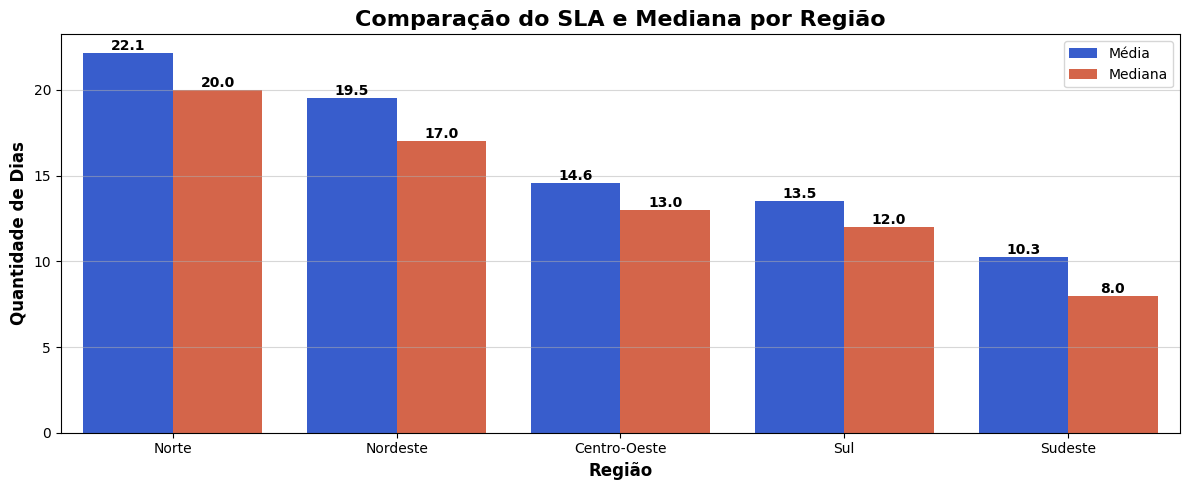

In [39]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=sla_plot,
    x='Região',
    y='value',
    hue='metric',
    alpha=1,
    palette=['#1F51E5', '#EB5733']
)

plt.title('Comparação do SLA e Mediana por Região', fontsize=16, weight='bold')
plt.xlabel('Região', fontsize=12, weight='bold')
plt.ylabel('Quantidade de Dias', fontsize=12, weight='bold')
plt.legend(title='')

plt.grid(axis='y', alpha=0.5)

for p in ax.patches:
    height = p.get_height()

    if not np.isnan(height) and height > 0.5:
        ax.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold'
        )

plt.tight_layout()
plt.show()

In [40]:
freight = logistica.groupby('region')['freight_value'].agg(['mean', 'median']
).reset_index().sort_values(by='mean', ascending=False)

freight.columns = ['Região', 'Média', 'Mediana']

freight_plot = freight.melt(
    id_vars='Região',
    value_vars=['Média', 'Mediana'],
    var_name='metric',
    value_name='value'
)

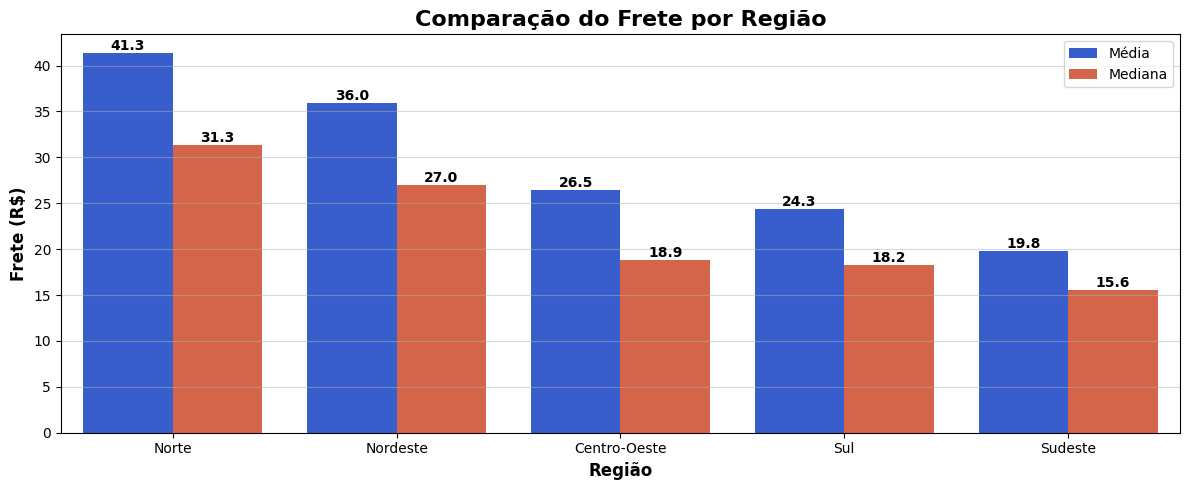

In [41]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    data=freight_plot,
    x='Região',
    y='value',
    hue='metric',
    alpha=1,
    palette=['#1F51E5', '#EB5733']
)

plt.title('Comparação do Frete por Região', fontsize=16, weight='bold')
plt.xlabel('Região', fontsize=12, weight='bold')
plt.ylabel('Frete (R$)', fontsize=12, weight='bold')
plt.legend(title='')
plt.grid(axis='y', alpha=0.5)

for p in ax.patches:
    height = p.get_height()

    if not np.isnan(height) and height > 0.5:
        ax.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold'
        )

plt.tight_layout()
plt.show()

In [42]:
entrega_status = logistica.groupby('region')['sla_status'] \
  .value_counts(normalize=True).reset_index()

entrega_status['proportion'] = entrega_status['proportion']*100

entrega_status_tabela = entrega_status.pivot(
    index='region',
    columns='sla_status',
    values='proportion'
).fillna(0).sort_values(by='Atrasado', ascending=True)

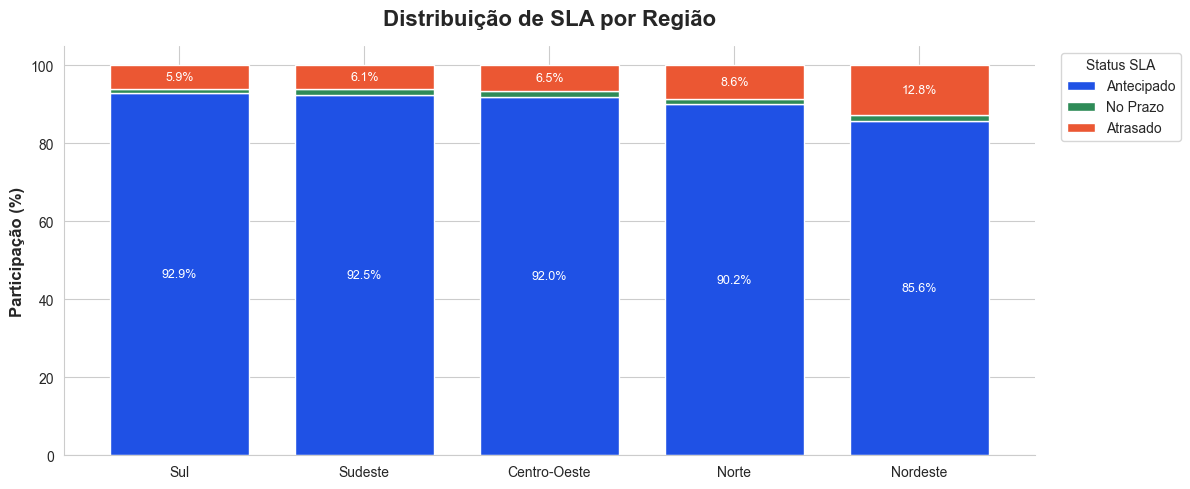

In [43]:
ordem_status = ['Antecipado', 'No Prazo', 'Atrasado']

grafico = entrega_status_tabela[ordem_status]

cores = [
    '#1F51E5',
    '#2E8B57',
    '#EB5733'
]

sns.set_style("whitegrid")

ax = grafico.plot(
    kind='bar',
    stacked=True,
    figsize=(12,5),
    width=0.75,
    color=cores
)

plt.title(
    'Distribuição de SLA por Região',
    fontsize=16,
    weight='bold',
    pad=15
)

plt.xlabel('')
plt.ylabel('Participação (%)', fontsize=12, weight='bold')
plt.xticks(rotation=0)

plt.legend(
    title='Status SLA',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

for container in ax.containers:
    labels = [
        f'{bar.get_height():.1f}%'
        if bar.get_height() > 3 else ''
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Satisfação do cliente

In [44]:
review = logistica.merge(df_review[['order_id', 'review_score', 'with_review_title', 'with_review_message']], on='order_id', how='left')

review = review[['order_id', 'customer_id', 'customer_state', 'region', 'freight_value', 'delivery_days', 'delay_days', 'sla_status', 'with_review_title', 'with_review_message', 'review_score']]

review.head()

,order_id,customer_id,customer_state,region,freight_value,delivery_days,delay_days,sla_status,with_review_title,with_review_message,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,Sudeste,8.72,8,-8,Antecipado,False,True,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,Nordeste,22.76,13,-6,Antecipado,True,True,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,Centro-Oeste,19.22,9,-18,Antecipado,False,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN,Nordeste,27.20,13,-13,Antecipado,False,True,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP,Sudeste,8.72,2,-10,Antecipado,False,False,5.0


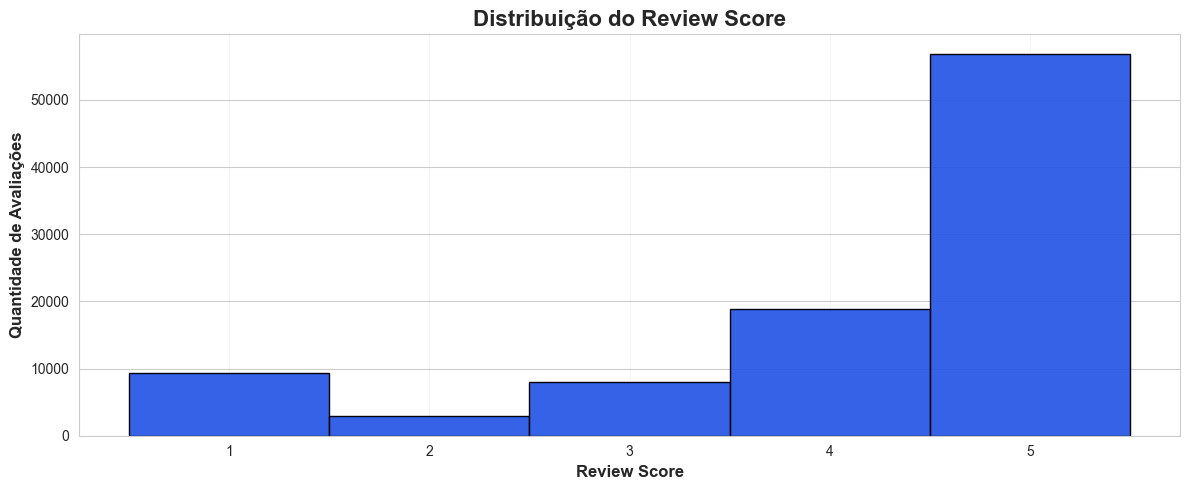

In [45]:
plt.figure(figsize=(12,5))

sns.histplot(
    data=review,
    x='review_score',
    bins=5,
    discrete=True,
    color='#1F51E5',
    edgecolor='black',
    alpha=0.9
)

plt.title('Distribuição do Review Score', fontsize=16, weight='bold')
plt.xlabel('Review Score', fontsize=12, weight='bold')
plt.ylabel('Quantidade de Avaliações', fontsize=12, weight='bold')
plt.xticks([1,2,3,4,5])
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

In [46]:
review['sla_group'] = np.where(
    review['sla_status'] == 'Atrasado',
    'Atrasado',
    'No Prazo / Antecipado'
)

grafico = (
    review
    .groupby(['region', 'sla_group'])['review_score']
    .mean()
    .reset_index()
)

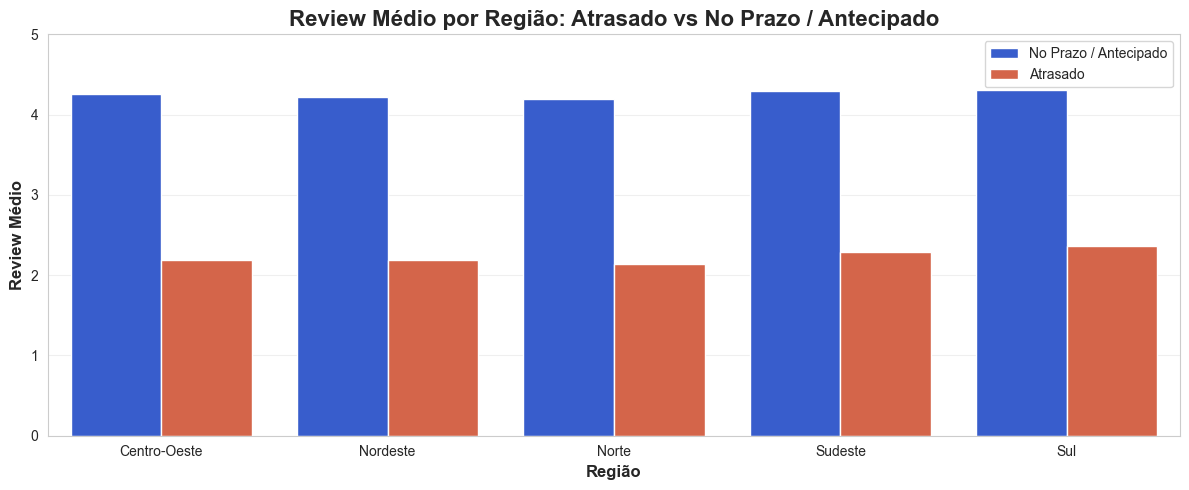

In [47]:
review['sla_group'] = np.where(
    review['sla_status'] == 'Atrasado',
    'Atrasado',
    'No Prazo / Antecipado'
)

grafico = (
    review
    .groupby(['region', 'sla_group'])['review_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=grafico,
    x='region',
    y='review_score',
    hue='sla_group',
    hue_order=['No Prazo / Antecipado', 'Atrasado'],
    palette=['#1F51E5', '#EB5733']
)

plt.title('Review Médio por Região: Atrasado vs No Prazo / Antecipado', fontsize=16, weight='bold')
plt.xlabel('Região', fontsize=12, weight='bold')
plt.ylabel('Review Médio', fontsize=12, weight='bold')
plt.ylim(0,5)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [48]:
atraso_estado = review.groupby('customer_state')['sla_status'] \
  .value_counts(normalize=True).reset_index()

atraso_estado['proportion'] = atraso_estado['proportion']*100

atraso_estado = atraso_estado.pivot(
    index='customer_state',
    columns='sla_status',
    values='proportion'
).fillna(0)

review_state = review.groupby('customer_state')['review_score'] \
  .mean().reset_index()

atraso_review = atraso_estado.merge(review_state, on='customer_state', how='left')

atraso_review = add_region(atraso_review, 'customer_state')

atraso_review = atraso_review.drop(columns=['No Prazo', 'Antecipado'])

atraso_review.head()


,customer_state,Atrasado,review_score,region
0,AC,3.750000,4.087500,Norte
1,AL,21.500000,3.841310,Nordeste
2,AM,2.739726,4.220690,Norte
3,AP,2.985075,4.242424,Norte
4,BA,12.232416,3.929078,Nordeste


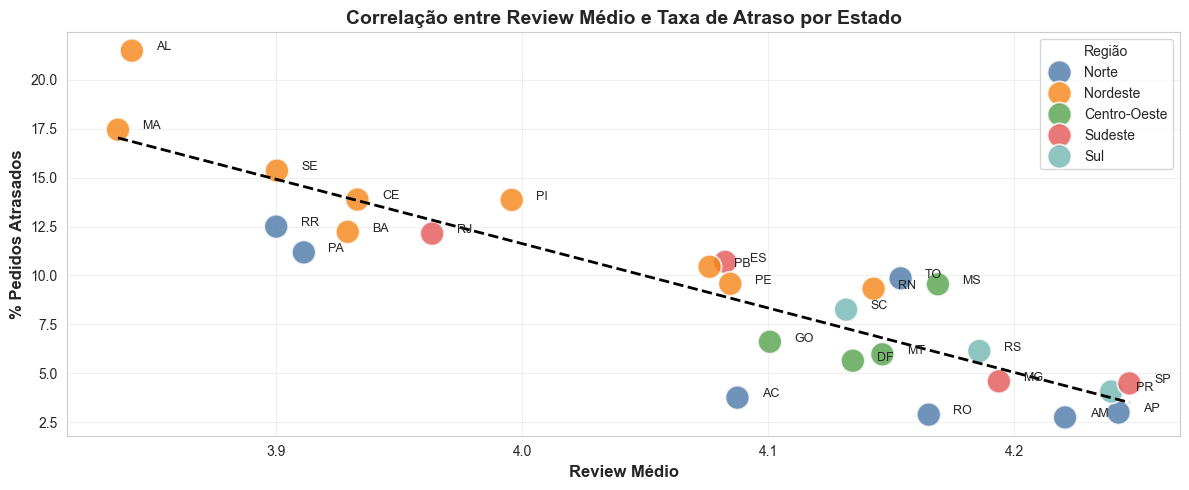

In [49]:
#ajustar a cor de acordo com TOP 10 estados

plt.figure(figsize=(12,5))

sns.scatterplot(
    data=atraso_review,
    x='review_score',
    y='Atrasado',
    hue='region',
    palette=region_colors,
    s=300,
    alpha=0.80
)

sns.regplot(
    data=atraso_review,
    x='review_score',
    y='Atrasado',
    scatter=False,
    ci=None,
    line_kws={
        'linewidth':2,
        'linestyle':'--',
        'color':'black'
    }
)

for _, row in atraso_review.iterrows():
    plt.text(
        row['review_score'] + 0.01,
        row['Atrasado'] + 0.01,
        row['customer_state'],
        fontsize=9
    )

plt.title('Correlação entre Review Médio e Taxa de Atraso por Estado', fontsize=14, weight='bold')
plt.xlabel('Review Médio', fontsize=12, weight='bold')
plt.ylabel('% Pedidos Atrasados', fontsize=12, weight='bold')
plt.grid(alpha=0.3)

plt.legend(title='Região')
plt.tight_layout()
plt.show()

In [50]:
frete_estado = review.groupby('customer_state').agg(
                      freight_value=('freight_value', 'mean'),
                      review_score=('review_score', 'mean')
                  ).reset_index()

frete_estado = add_region(frete_estado, 'customer_state')

frete_estado


,customer_state,freight_value,review_score,region
0,AC,45.554500,4.087500,Norte
1,AL,38.472225,3.841310,Nordeste
2,AM,37.375822,4.220690,Norte
3,AP,41.298507,4.242424,Norte
4,BA,29.943520,3.929078,Nordeste
5,CE,36.526110,3.933018,Nordeste
6,DF,23.866378,4.134422,Centro-Oeste
7,ES,24.539715,4.082532,Sudeste
8,GO,26.300783,4.100716,Centro-Oeste
9,MA,42.758408,3.835674,Nordeste


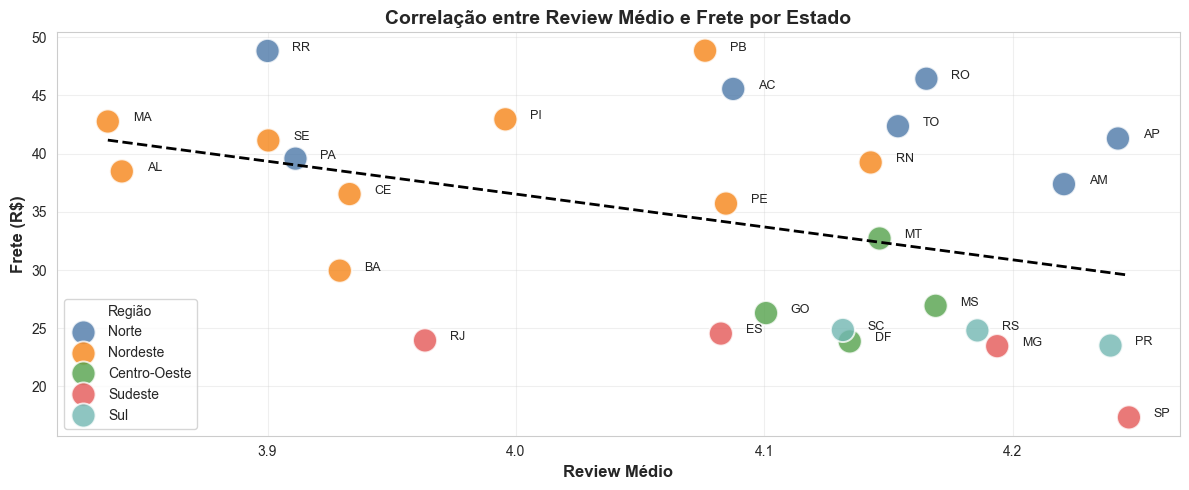

In [51]:
#ajustar a cor de acordo com TOP 10 estados

plt.figure(figsize=(12,5))

sns.scatterplot(
    data=frete_estado,
    x='review_score',
    y='freight_value',
    hue='region',
    palette=region_colors,
    s=300,
    alpha=0.80
)

sns.regplot(
    data=frete_estado,
    x='review_score',
    y='freight_value',
    scatter=False,
    ci=None,
    line_kws={
        'linewidth':2,
        'linestyle':'--',
        'color':'black'
    }
)

for _, row in frete_estado.iterrows():
    plt.text(
        row['review_score'] + 0.01,
        row['freight_value'] + 0.01,
        row['customer_state'],
        fontsize=9
    )

plt.title('Correlação entre Review Médio e Frete por Estado', fontsize=14, weight='bold')
plt.xlabel('Review Médio', fontsize=12, weight='bold')
plt.ylabel('Frete (R$)', fontsize=12, weight='bold')
plt.grid(alpha=0.3)

plt.legend(title='Região')
plt.tight_layout()
plt.show()

## Análise de texto (Reviews)

In [52]:
## Analisar quais as palavras chaves de pedidos

In [53]:
review_text = df_review[df_review['with_review_message'] == True].copy()

review_text = review_text.merge(logistica[['order_id', 'sla_status']], on='order_id', how='left')

review_text.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,with_review_title,with_review_message,sla_status
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,False,True,Antecipado
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,False,True,Antecipado
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47,True,True,Antecipado
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16,2018-02-20 10:52:22,False,True,Antecipado
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23,2018-05-24 03:00:01,True,True,Antecipado


In [54]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vinicius\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [55]:
stop_words = set(stopwords.words('portuguese'))

extras = {
    # genéricas
    'dentro','dia','dias','sempre','certo','porem',

    # positivas vagas
    'otimo','otima','excelente','bom','boa',
    'perfeito','parabens','rapido','rapida', 'nao', 'sim',

    # contexto
    'site','produtos','produto','pedido','compra'
}

stop_words.update(extras)

In [56]:
review_text['texto'] = (
    review_text['review_comment_title'].fillna('') + ' ' +
    review_text['review_comment_message'].fillna('')
)

In [57]:
tokens_geral = []

for texto in review_text['texto']:
    tokens_geral.extend(limpar_texto(texto))

freq_geral = Counter(tokens_geral).most_common(15)

freq_geral = pd.DataFrame(freq_geral, columns=['palavra', 'freq'])
freq_geral

,palavra,freq
0,prazo,8432
1,entrega,6975
2,recomendo,5896
3,ante,5677
4,chegou,5577
5,recebi,5508
6,entregue,4057
7,veio,3325
8,bem,3104
9,loja,2888


In [58]:
ruins = review_text[review_text['review_score'].isin([1,2])]

tokens_ruins = []

for texto in ruins['texto']:
    tokens_ruins.extend(limpar_texto(texto))

freq_ruins = Counter(tokens_ruins).most_common(15)

freq_ruins = pd.DataFrame(freq_ruins, columns=['palavra', 'freq'])
freq_ruins

,palavra,freq
0,recebi,3467
1,comprei,1880
2,veio,1599
3,entrega,1555
4,entregue,1485
5,ainda,1429
6,ate,1418
7,chegou,1223
8,prazo,932
9,loja,926


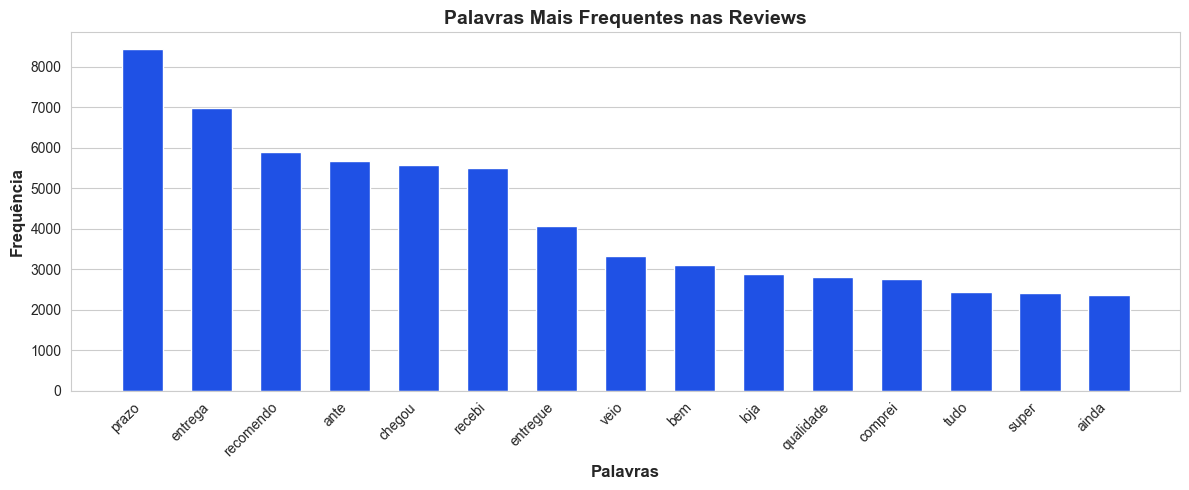

In [59]:
x = np.arange(len(freq_geral))

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    x,
    freq_geral['freq'],
    color='#1F51E5',
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(
    freq_geral['palavra'],
    rotation=45,
    ha='right'
)

ax.set_ylabel('Frequência', fontsize=12, weight='bold')
ax.set_xlabel('Palavras', fontsize=12, weight='bold')

plt.title(
    'Palavras Mais Frequentes nas Reviews',
    fontsize=14,
    weight='bold'
)

ax.grid(axis='x', alpha=0)

plt.tight_layout()
plt.show()


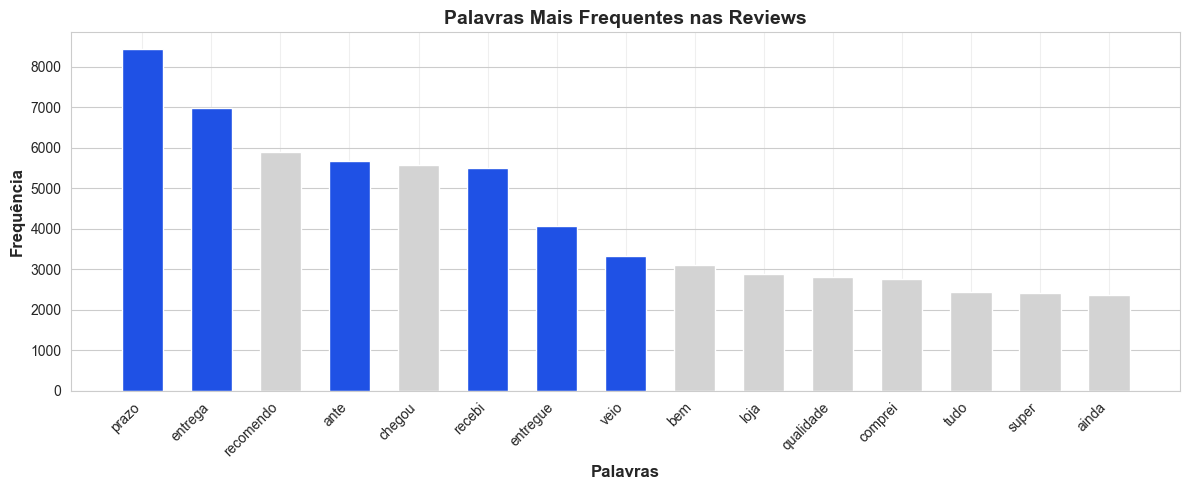

In [60]:
#Destacar palavras de logistica

x = np.arange(len(freq_geral))

palavras_destaque = ['prazo', 'entrega', 'ante', 'Chegou', 'recebi', 'entregue', 'veio']

colors = [
    '#1F51E5' if palavra in palavras_destaque else '#D3D3D3'
    for palavra in freq_geral['palavra']
]

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    x,
    freq_geral['freq'],
    color=colors,
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(
    freq_geral['palavra'],
    rotation=45,
    ha='right'
)

ax.set_ylabel('Frequência', fontsize=12, weight='bold')
ax.set_xlabel('Palavras', fontsize=12, weight='bold')

plt.title(
    'Palavras Mais Frequentes nas Reviews',
    fontsize=14,
    weight='bold'
)

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

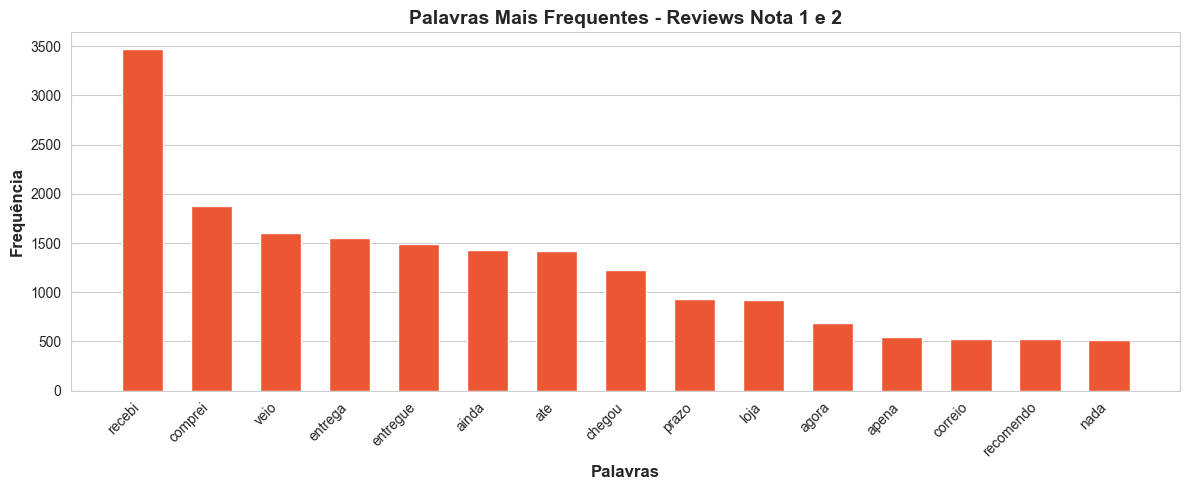

In [61]:
x = np.arange(len(freq_ruins))

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    x,
    freq_ruins['freq'],
    color='#EB5733',
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(
    freq_ruins['palavra'],
    rotation=45,
    ha='right'
)

ax.set_ylabel('Frequência', fontsize=12, weight='bold')
ax.set_xlabel('Palavras', fontsize=12, weight='bold')

plt.title(
    'Palavras Mais Frequentes - Reviews Nota 1 e 2',
    fontsize=14,
    weight='bold'
)

ax.grid(axis='x', alpha=0)

plt.tight_layout()
plt.show()

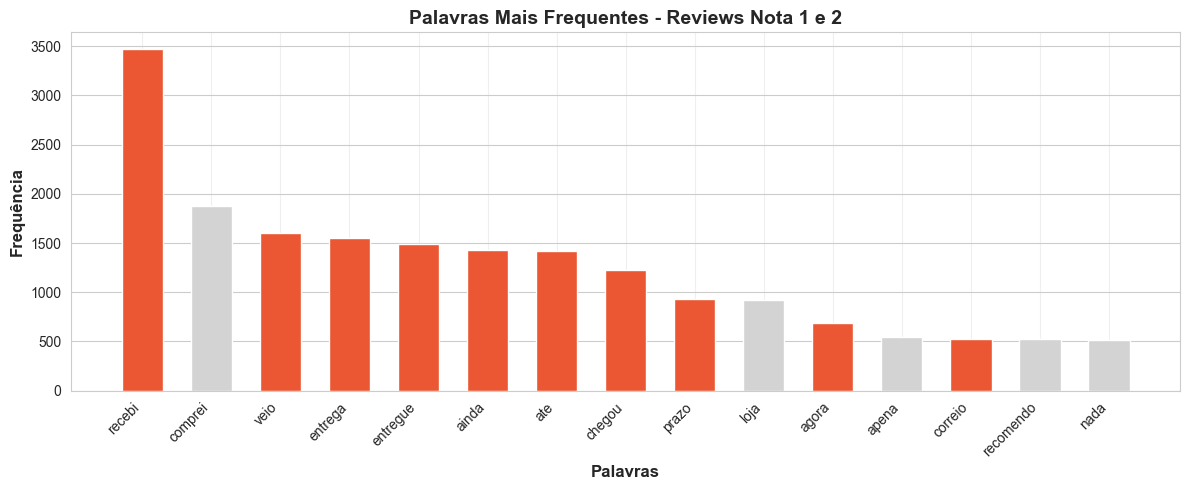

In [62]:
x = np.arange(len(freq_ruins))

palavras_destaque = ['recebi', 'veio', 'entrega', 'entregue', 'ainda', 'ate', 'chegou', 'prazo', 'agora', 'correio' ]

colors = [
    '#EB5733' if palavra in palavras_destaque else '#D3D3D3'
    for palavra in freq_ruins['palavra']
]

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    x,
    freq_ruins['freq'],
    color=colors,
    width=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(
    freq_ruins['palavra'],
    rotation=45,
    ha='right'
)

ax.set_ylabel('Frequência', fontsize=12, weight='bold')
ax.set_xlabel('Palavras', fontsize=12, weight='bold')

plt.title(
    'Palavras Mais Frequentes - Reviews Nota 1 e 2',
    fontsize=14,
    weight='bold'
)

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Taxa de recompra

In [63]:
recompra = df_orders[(df_orders['flag_order_complete'] == True)  & (df_orders['order_purchase_timestamp'] > '2017-01-01')]

recompra = recompra.merge(df_customers, on='customer_id', how='left')

recompra = recompra.merge(logistica[['order_id','sla_status']], on='order_id', how='left')

In [64]:
recompra['monthyear_purchase'] = recompra['order_purchase_timestamp'].dt.to_period('M')

recompra['monthyear_cohort'] = recompra.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

recompra['cohort_index'] = (recompra['monthyear_purchase'] - recompra['monthyear_cohort']).apply(lambda x: x.n)


In [65]:
cohort_data = recompra.groupby(['monthyear_cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

cohort_data.columns = ['cohort_date', 'cohort_index', 'num_customers']

In [66]:
cohort_counts = cohort_data.pivot_table(
    index='cohort_date',
    columns='cohort_index',
    values='num_customers',
    aggfunc='sum'
)

In [67]:
cohort_sizes = cohort_counts.iloc[:, 0]

cohort_retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

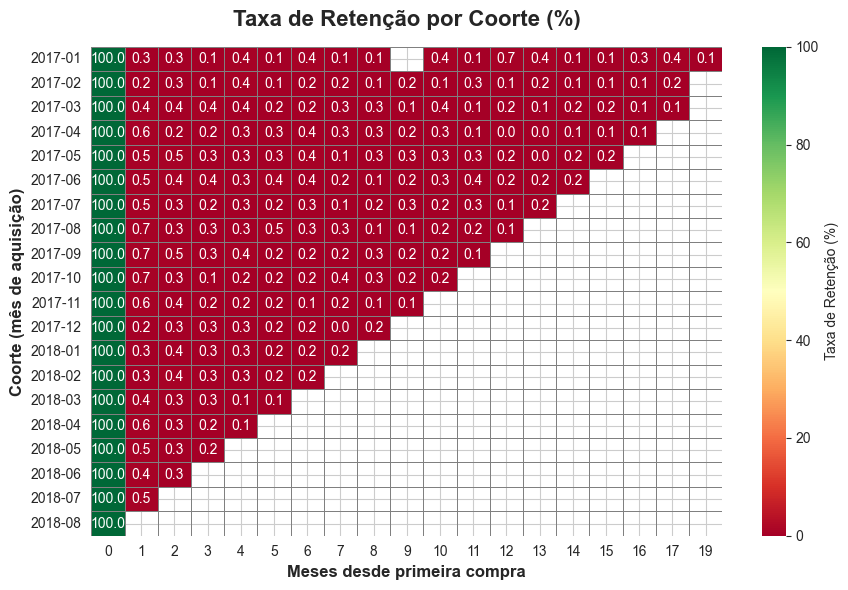

In [68]:
plt.figure(figsize=(9,6))

sns.heatmap(
    cohort_retention,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Taxa de Retenção (%)'}
)

plt.title('Taxa de Retenção por Coorte (%)', fontsize=16, weight='bold', pad=15)
plt.xlabel('Meses desde primeira compra', fontsize=12, weight='bold')
plt.ylabel('Coorte (mês de aquisição)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

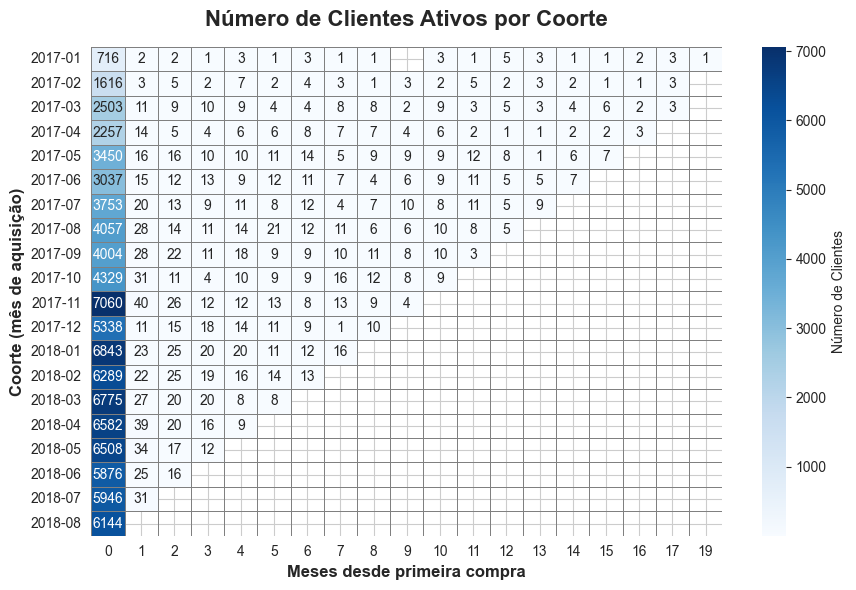

In [69]:
plt.figure(figsize=(9,6))

sns.heatmap(
    cohort_counts,
    annot=True,
    fmt='g',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Número de Clientes'}
)

plt.title('Número de Clientes Ativos por Coorte', fontsize=16, weight='bold', pad=15)
plt.xlabel('Meses desde primeira compra', fontsize=12, weight='bold')
plt.ylabel('Coorte (mês de aquisição)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

In [70]:
recompra = df_orders[(df_orders['flag_order_complete'] == True) & (df_orders['order_purchase_timestamp'] > '2017-01-01')].copy()

recompra = recompra.merge(df_customers, on='customer_id', how='left')

recompra = recompra.merge(logistica[['order_id', 'sla_status']], on='order_id', how='left')

recompra['order_purchase_timestamp'] = pd.to_datetime(recompra['order_purchase_timestamp'])

In [71]:
recompra = recompra.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

primeira_compra = (recompra.groupby('customer_unique_id').first().reset_index())

primeira_compra = primeira_compra[['customer_unique_id', 'sla_status', 'order_purchase_timestamp']].rename(columns={
    'sla_status': 'first_purchase_sla',
    'order_purchase_timestamp': 'first_purchase_date'
})

recompra = recompra.merge(primeira_compra,on='customer_unique_id',how='left')

In [72]:
recompra['first_purchase_sla_group'] = np.where(
    recompra['first_purchase_sla'] == 'Atrasado',
    'Atrasado',
    'No Prazo / Antecipado'
)

In [73]:
recompra['monthyear_purchase'] = (recompra['order_purchase_timestamp'].dt.to_period('M'))

recompra['monthyear_cohort'] = (recompra['first_purchase_date'].dt.to_period('M'))

recompra['cohort_index'] = (recompra['monthyear_purchase'] -recompra['monthyear_cohort']).apply(lambda x: x.n)

In [74]:
cohort_data = (recompra.groupby(['first_purchase_sla_group','monthyear_cohort','cohort_index'])['customer_unique_id'].nunique().reset_index())

cohort_data.columns = ['first_purchase_sla', 'cohort_date', 'cohort_index', 'num_customers']

In [75]:
ret_atrasado, count_atrasado = cohort_tables(cohort_data, 'Atrasado')

ret_prazo, count_prazo = cohort_tables(cohort_data, 'No Prazo / Antecipado')

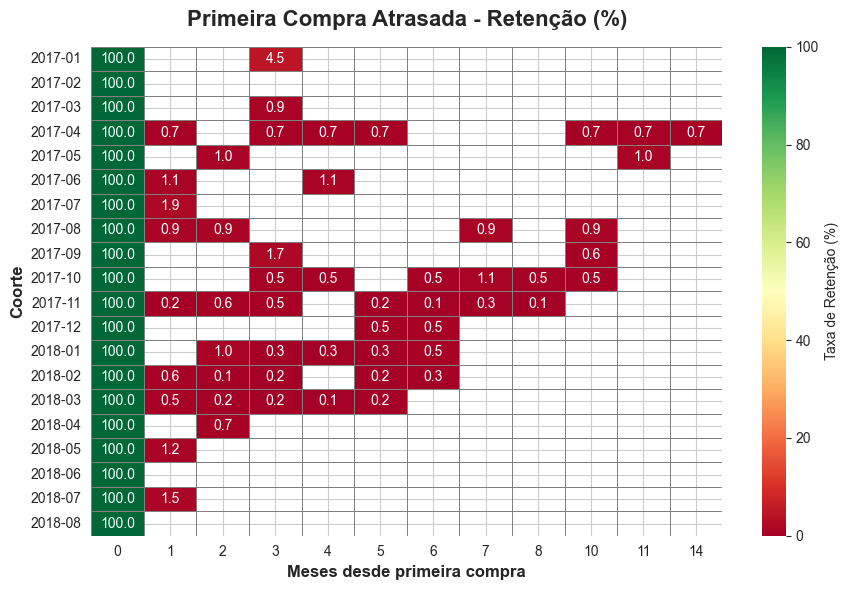

In [76]:
plt.figure(figsize=(9,6))

sns.heatmap(
    ret_atrasado,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Taxa de Retenção (%)'}
)

plt.title(
    'Primeira Compra Atrasada - Retenção (%)',
    fontsize=16,
    weight='bold',
    pad=15
)

plt.xlabel('Meses desde primeira compra', fontsize=12, weight='bold')
plt.ylabel('Coorte', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

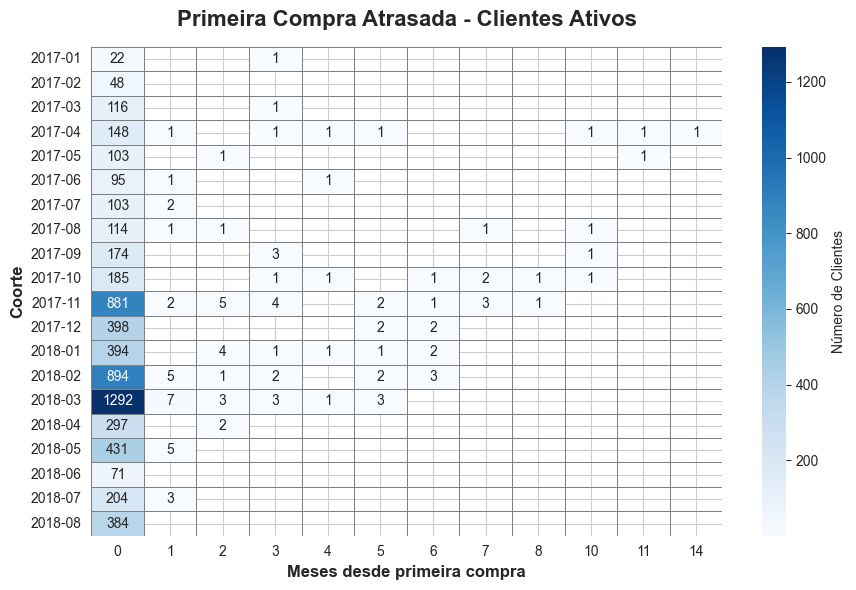

In [77]:
plt.figure(figsize=(9,6))

sns.heatmap(
    count_atrasado,
    annot=True,
    fmt='g',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Número de Clientes'}
)

plt.title(
    'Primeira Compra Atrasada - Clientes Ativos',
    fontsize=16,
    weight='bold',
    pad=15
)

plt.xlabel('Meses desde primeira compra', fontsize=12, weight='bold')
plt.ylabel('Coorte', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

# Recomendações

## Sellers

In [78]:
sellers = df_sellers.copy()

sellers = sellers.merge(df_items, on='seller_id', how='left')

sellers = sellers.merge(df_orders, on='order_id', how='left')

sellers = sellers.merge(df_customers, on='customer_id', how='left')

In [79]:
sellers['lt_shipping'] =  (sellers['order_delivered_carrier_date'] - sellers['shipping_limit_date']).dt.days

sellers['shipping_status'] = np.where(
    sellers['lt_shipping'] <= 0,
    'No Prazo',
    'Atrasado' )

sellers['delay_days'] = (
    sellers['order_delivered_customer_date'] -
    sellers['order_estimated_delivery_date']
).dt.days

sellers['sla_status'] = 'No Prazo'

sellers.loc[sellers['delay_days'] < 0, 'sla_status'] = 'Antecipado'
sellers.loc[sellers['delay_days'] > 0, 'sla_status'] = 'Atrasado'

In [80]:
sellers = sellers[['seller_id', 'seller_state', 'region_x', 'order_id', 'order_item_id' ,'product_id', 'shipping_limit_date', 'price', 'freight_value', 'total_price', 'flag_order_complete', 'customer_id', 'customer_state', 'region_y', 'lt_shipping', 'shipping_status', 'delay_days', 'sla_status']]

In [81]:
sellers = sellers.rename(columns={'region_x': 'seller_region', 'region_y': 'customer_region'})

sellers.head()

,seller_id,seller_state,seller_region,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,total_price,flag_order_complete,customer_id,customer_state,customer_region,lt_shipping,shipping_status,delay_days,sla_status
0,3442f8959a84dea7ee197c632cb2df15,SP,Sudeste,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56,115.76,True,9d6837f9700a3441e7183bff3bc4eef0,SP,Sudeste,3.0,Atrasado,-2.0,Antecipado
1,3442f8959a84dea7ee197c632cb2df15,SP,Sudeste,6d953888a914b67350d5bc4d48f2acab,1,f4621f8ad6f54a2e3c408884068be46d,2017-05-11 16:25:11,101.70,15.92,117.62,True,a973c4e3ad82777add3fa188f91dacea,MG,Sudeste,0.0,No Prazo,3.0,Atrasado
2,3442f8959a84dea7ee197c632cb2df15,SP,Sudeste,bc8a5de6abf5b14f98a6135a7fb46731,2,325a06bcce0da45b7f4ecf2797dd40e4,2017-09-05 12:50:19,10.80,2.42,13.22,True,1554ffe702931a062b4383b109accf63,SP,Sudeste,-6.0,No Prazo,-19.0,Antecipado
3,d1b65fc7debc3361ea86b5f14c68d2e2,SP,Sudeste,035201c3c82a97f8a25dd6bd5244b2d5,1,1c36a5285f7f3b1ed2637d7c528ce5ff,2017-11-22 04:30:29,89.99,45.09,135.08,True,9facbfd2dd51a45404d58154b12ed2dd,RJ,Sudeste,-8.0,No Prazo,-13.0,Antecipado
4,d1b65fc7debc3361ea86b5f14c68d2e2,SP,Sudeste,0504447548229e075dea8441b37b1e2a,1,8852eb03b04ec3268a66e9b696e25f6f,2017-10-06 02:14:42,199.90,21.89,221.79,True,4e2c1f15de98416a90c2ee06b55ccc9b,RS,Sul,-4.0,No Prazo,-28.0,Antecipado


In [128]:
sellers_region = sellers.groupby('seller_region').agg(
    pedidos=('order_id', 'nunique'),
    qtd_sellers=('seller_id', 'count'),
    receita=('total_price', 'sum')).reset_index()

sellers_region['sellers_share'] = round((sellers_region['qtd_sellers'] / sellers_region['qtd_sellers'].sum())*100,2)

sellers_region.head()

,seller_region,pedidos,qtd_sellers,receita,sellers_share
0,Centro-Oeste,1473,1614,226661.35,1.43
1,Nordeste,1566,1706,517070.13,1.51
2,Norte,26,26,8426.73,0.02
3,Sudeste,82583,94359,12457718.54,83.76
4,Sul,13316,14945,2633676.49,13.27


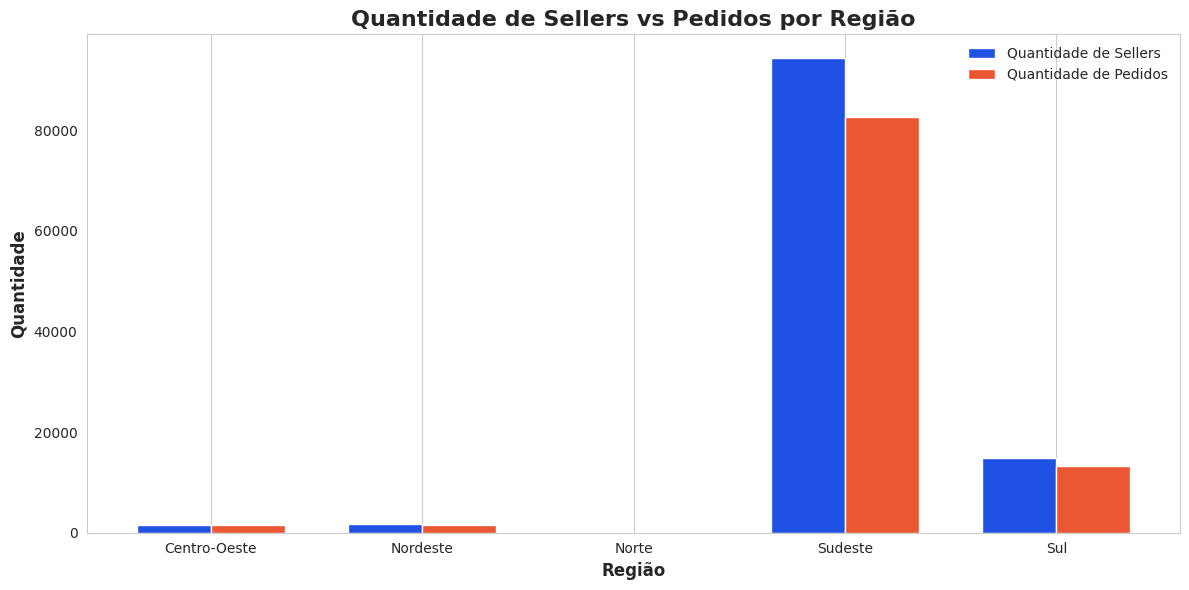

In [127]:
x = np.arange(len(sellers_region))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(
    x - width/2,
    sellers_region['qtd_sellers'],
    width,
    color='#1F51E5',
    label='Quantidade de Sellers'
)

bars2 = ax.bar(
    x + width/2,
    sellers_region['pedidos'],
    width,
    color='#EB5733',
    label='Quantidade de Pedidos'
)

ax.set_xticks(x)
ax.set_xticklabels(
    sellers_region['seller_region'],
    rotation=0
)

ax.set_ylabel('Quantidade', fontsize=12, weight='bold')
ax.set_xlabel('Região', fontsize=12, weight='bold')

plt.title('Quantidade de Sellers vs Pedidos por Região', fontsize=16, weight='bold')

ax.grid(axis='y', linestyle='--', alpha=0)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Recomendações

#### SLA
1.	Revisar os prazos prometidos para as regiões Norte e Nordeste aumentando a margem de segurança em 20% para transformar pedidos atrasados em entregas no prazo, atendo a expectativa do cliente e elevando a nota média sem alterar a operação física.
2.	Automatizar o disparo de cupons de desconto exclusivos para clientes que sofreram atraso para quebrar a tendência de 100% de churn, incentivando uma segunda chance à plataforma e gerar recomendações pelo pós-compra.
3.	Permitir subsídios de frete (Frete Grátis ou Reduzido) como ferramenta de conversão para compensar prazos de entrega mais longos em regiões de difícil acesso.

#### Sellers
1.	Criar incentivos ou campanhas para a entrada de novos sellers em outras regiões, principalmente Norte e Nordeste, reduzindo a distância entre o estoque e o consumidor final.
2.	Implementar um sistema de pontuação para sellers baseado em performance logística e review score. Exemplo: A, B, C, D e E.
  - A/B: Prioridade em algoritmos de busca e parcerias de frete.
  - C/D/E: Acesso obrigatório a trilhas de treinamento focada em logística e proteção do produto.
3.	Implementar um indicador de confiança para sellers baseada no sistema de pontuação, reduzindo a ansiedade e insegurança do comprador.
